# Random Forest Modeling

This notebook builds and evaluates a Random Forest model for loan default prediction using the feature-engineered LendingClub dataset.

The target variable is `loan_status`, where:
- `0` = non-default loan
- `1` = default loan

Because the default class accounts for about 20% of the dataset, this is an imbalanced binary classification problem.

In [20]:
from pathlib import Path

data_path = Path("data/processed/features.parquet")

print("Exists:", data_path.exists())
print("Path:", data_path.resolve())
print("Size MB:", data_path.stat().st_size / 1024 / 1024)

Exists: True
Path: /Users/bernadette/STAT-GR5243-Project-4/data/processed/features.parquet
Size MB: 129.26392936706543


In [21]:
import pandas as pd
from pathlib import Path

data_path = Path("data/processed/features.parquet")

df = pd.read_parquet(data_path, engine="fastparquet")

print("Shape:", df.shape)
df.head()

Shape: (1345310, 75)


,loan_amnt,term,sub_grade,emp_length,annual_inc,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,...,purpose_medical,purpose_moving,purpose_other,purpose_small_business,purpose_vacation,verification_status_Source Verified,verification_status_Verified,application_type_Joint App,initial_list_status_w,loan_status
0,-1.241243,36,0.357677,1.139682,-0.303863,0.414094,-1.108755,-0.361956,0.367807,-1.040591,...,0,0,0,0,0,0,0,0,1,0
1,1.179302,36,-0.107446,1.139682,-0.160853,0.657298,-0.199167,0.777007,3.566874,-1.286574,...,0,0,0,1,0,0,0,0,1,0
2,0.640128,60,-0.417528,1.139682,-0.189455,-0.934547,-0.672332,-0.361956,-0.698549,0.978521,...,0,0,0,0,0,0,0,1,1,0
3,-0.461162,60,2.218168,-0.680776,0.403080,0.414094,0.635145,0.777007,2.500519,-1.225078,...,0,0,0,0,0,1,0,0,1,0
4,-0.283350,36,0.202636,-0.420711,-0.604184,-0.786496,-0.724308,-0.361956,-0.698549,0.978521,...,0,0,0,0,0,1,0,0,1,0


In [22]:
print(df.columns.tolist())
print(df.dtypes.value_counts())

['loan_amnt', 'term', 'sub_grade', 'emp_length', 'annual_inc', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'tot_coll_amt', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'credit_age_months', 'fico_avg', 'installment_to_income', 'revol_bal_to_inco

In [23]:
[col for col in df.columns if "target" in col.lower() or "default" in col.lower() or "status" in col.lower() or "loan" in col.lower()]

['loan_amnt',
 'verification_status_Source Verified',
 'verification_status_Verified',
 'initial_list_status_w',
 'loan_status']

In [24]:
target_col = "loan_status"

print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True))

loan_status
0    1076751
1     268559
Name: count, dtype: int64
loan_status
0    0.800374
1    0.199626
Name: proportion, dtype: float64


In [25]:
target_col = "loan_status"

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

X shape: (1345310, 74)
y shape: (1345310,)
Target distribution:
loan_status
0    0.800374
1    0.199626
Name: proportion, dtype: float64


## Train-Test Split

We use an 80/20 stratified train-test split to preserve the default/non-default class distribution in both training and testing sets.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (1076248, 74)
Test shape: (269062, 74)
Train target distribution:
loan_status
0    0.800374
1    0.199626
Name: proportion, dtype: float64
Test target distribution:
loan_status
0    0.800373
1    0.199627
Name: proportion, dtype: float64


## Baseline Random Forest

The first Random Forest model is trained on the full training dataset with class weighting. Class weighting is used because default loans are the minority class.

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

rf_full = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=30,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_full.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 tasks      | elapsed:   20.4s
[Parallel(n_jobs=-1)]: Done 172 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.5min finished


RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                       min_samples_leaf=30, n_estimators=200, n_jobs=-1,
                       random_state=42, verbose=1)

In [30]:
y_pred_full = rf_full.predict(X_test)
y_prob_full = rf_full.predict_proba(X_test)[:, 1]

rf_full_metrics = {
    "model": "Random Forest Full Training Data",
    "accuracy": accuracy_score(y_test, y_pred_full),
    "precision": precision_score(y_test, y_pred_full, zero_division=0),
    "recall": recall_score(y_test, y_pred_full, zero_division=0),
    "f1": f1_score(y_test, y_pred_full, zero_division=0),
    "auc": roc_auc_score(y_test, y_prob_full)
}

rf_full_metrics

[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.2s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:    1.2s
[Parallel(n_jobs=14)]: Done 200 out of 200 | elapsed:    1.4s finished
[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.1s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:    1.2s
[Parallel(n_jobs=14)]: Done 200 out of 200 | elapsed:    1.4s finished


{'model': 'Random Forest Full Training Data',
 'accuracy': 0.7081490511480625,
 'precision': 0.355997121567353,
 'recall': 0.5710455764075067,
 'f1': 0.4385786802030457,
 'auc': np.float64(0.7249474470175153)}

In [31]:
print(classification_report(y_test, y_pred_full, zero_division=0))

              precision    recall  f1-score   support

           0       0.87      0.74      0.80    215350
           1       0.36      0.57      0.44     53712

    accuracy                           0.71    269062
   macro avg       0.62      0.66      0.62    269062
weighted avg       0.77      0.71      0.73    269062



## Tuned Random Forest

We also tested a stronger Random Forest specification with more trees, greater tree depth, and smaller leaf size. The tuned model slightly improved AUC and precision, but reduced recall and F1-score.

In [32]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
a    min_samples_leaf=10,
    min_samples_split=50,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_tuned.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 tasks      | elapsed:   23.5s
[Parallel(n_jobs=-1)]: Done 172 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  3.8min finished


RandomForestClassifier(class_weight='balanced_subsample', max_depth=30,
                       min_samples_leaf=10, min_samples_split=50,
                       n_estimators=300, n_jobs=-1, random_state=42, verbose=1)

In [33]:
y_pred_tuned = rf_tuned.predict(X_test)
y_prob_tuned = rf_tuned.predict_proba(X_test)[:, 1]

rf_tuned_metrics = {
    "model": "Random Forest Tuned",
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "f1": f1_score(y_test, y_pred_tuned, zero_division=0),
    "auc": roc_auc_score(y_test, y_prob_tuned)
}

rf_tuned_metrics

[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.2s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:    1.7s
[Parallel(n_jobs=14)]: Done 300 out of 300 | elapsed:    2.8s finished
[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.2s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:    1.5s
[Parallel(n_jobs=14)]: Done 300 out of 300 | elapsed:    2.6s finished


{'model': 'Random Forest Tuned',
 'accuracy': 0.7439400584251957,
 'precision': 0.38602654176424667,
 'recall': 0.4787384569556151,
 'f1': 0.4274126525049034,
 'auc': np.float64(0.72613428287554)}

In [34]:
print(classification_report(y_test, y_pred_tuned, zero_division=0))

              precision    recall  f1-score   support

           0       0.86      0.81      0.84    215350
           1       0.39      0.48      0.43     53712

    accuracy                           0.74    269062
   macro avg       0.62      0.64      0.63    269062
weighted avg       0.77      0.74      0.75    269062



In [35]:
comparison_df = pd.DataFrame([rf_full_metrics, rf_tuned_metrics])
comparison_df

,model,accuracy,precision,recall,f1,auc
0,Random Forest Full Training Data,0.708149,0.355997,0.571046,0.438579,0.724947
1,Random Forest Tuned,0.743940,0.386027,0.478738,0.427413,0.726134


In [36]:
from pathlib import Path
import pandas as pd

results_path = Path("results")
figures_path = Path("figures")

results_path.mkdir(exist_ok=True)
figures_path.mkdir(exist_ok=True)

comparison_df = pd.DataFrame([rf_full_metrics, rf_tuned_metrics])
comparison_df.to_csv(results_path / "random_forest_model_comparison.csv", index=False)

comparison_df

,model,accuracy,precision,recall,f1,auc
0,Random Forest Full Training Data,0.708149,0.355997,0.571046,0.438579,0.724947
1,Random Forest Tuned,0.743940,0.386027,0.478738,0.427413,0.726134


## Final Random Forest Selection

Although the tuned Random Forest slightly improved accuracy, precision, and AUC, the full-training Random Forest achieved higher recall and F1-score. Since this is a credit-risk prediction task, missing default cases can be costly. Therefore, we report the balanced full-training Random Forest as the preferred Random Forest specification.

In [37]:
final_rf = rf_full
final_y_pred = y_pred_full
final_y_prob = y_prob_full
final_metrics = rf_full_metrics

In [38]:
pd.DataFrame([final_metrics]).to_csv(
    results_path / "random_forest_final_metrics.csv",
    index=False
)

pd.DataFrame([final_metrics])

,model,accuracy,precision,recall,f1,auc
0,Random Forest Full Training Data,0.708149,0.355997,0.571046,0.438579,0.724947


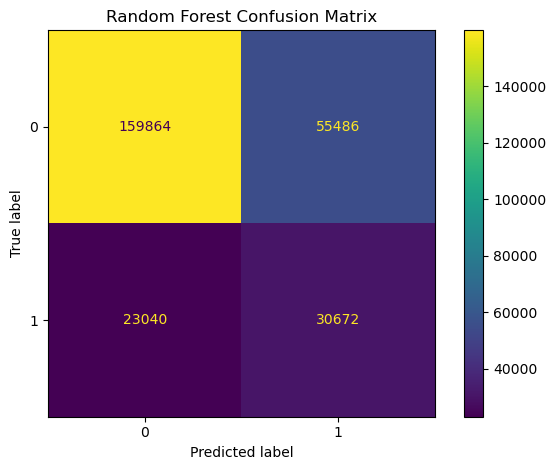

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, final_y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig(figures_path / "random_forest_confusion_matrix.png", dpi=200)
plt.show()

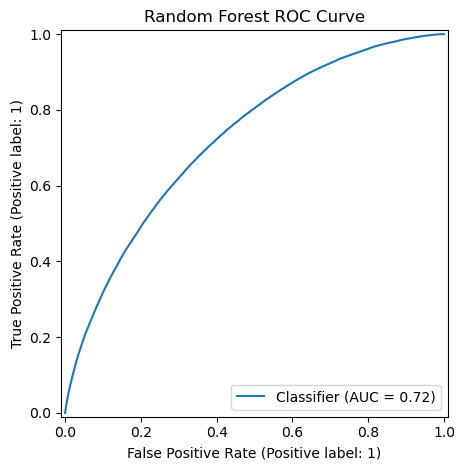

In [40]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, final_y_prob)
plt.title("Random Forest ROC Curve")
plt.tight_layout()
plt.savefig(figures_path / "random_forest_roc_curve.png", dpi=200)
plt.show()

## Feature Importance

The most important features include loan sub-grade, loan term, installment-to-income ratio, FICO score, debt-to-income ratio, and loan amount. These features are consistent with credit-risk intuition because they capture borrower credit quality, repayment burden, and loan characteristics.

In [41]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": final_rf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.to_csv(results_path / "random_forest_feature_importance.csv", index=False)

importance_df.head(20)

,feature,importance
2,sub_grade,0.169886
1,term,0.079636
52,installment_to_income,0.044687
51,fico_avg,0.042748
6,dti,0.037341
0,loan_amnt,0.026204
20,bc_open_to_buy,0.024063
19,avg_cur_bal,0.023788
46,tot_hi_cred_lim,0.023770
18,acc_open_past_24mths,0.022501


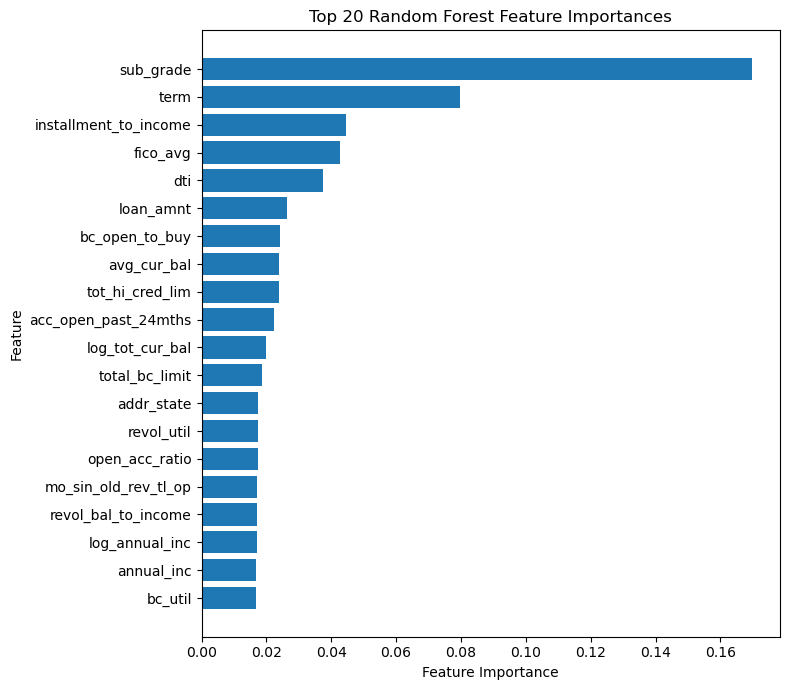

In [42]:
top_features = importance_df.head(20).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(figures_path / "random_forest_feature_importance.png", dpi=200)
plt.show()